<h1 style="text-align:center;">Song Success Prediction Model</h1>
<h2 style="text-align:center;">Modeling</h2>

<h4 style="text-align:center;">by Cameron Hicks</h3>

The Song Success Prediction Model project aims to create a Machine Learning Model that can predict the success and popularity of a song in the early or pre-release stages of production. The objective of this notebook is to train 3 Machine Learning Models and ultimately determine the best model to select as the final output of this project. In the steps below each model will be trained on the training data sets, then their accuracy will be tested using the test data sets. All three models will be objectively compared to make the final determination.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, 
    precision_score,
    recall_score,
    f1_score,
    auc,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay,
    classification_report,
    ConfusionMatrixDisplay,
    mean_absolute_error, 
    mean_squared_error, 
    r2_score
)

# Import Data

In [2]:
X_train_scaled = pd.read_csv('../Data/X_train_scaled.csv')
X_test_scaled = pd.read_csv('../Data/X_test_scaled.csv')
y_train = pd.read_csv('../Data/y_train.csv')
y_test = pd.read_csv('../Data/y_test.csv')

# Model 1 - Linear Regression

In [8]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [14]:
print("LINEAR REGRESSION RESULTS")

r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

LINEAR REGRESSION RESULTS
R2: -0.0009241185239940997
MAE: 11.51579485554882
RMSE: 14.832340251228054


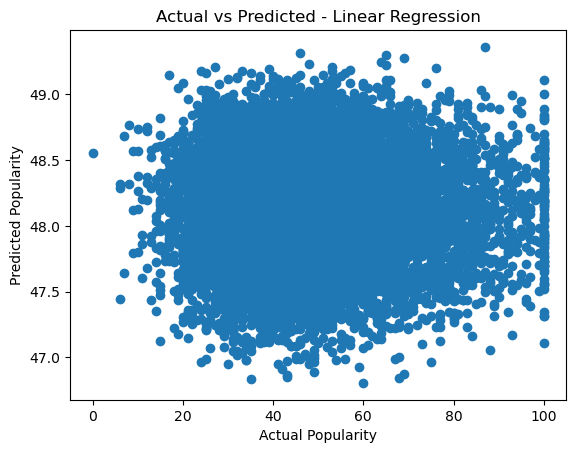

In [24]:
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Actual vs Predicted - Linear Regression")
plt.show()

# Model 2 - Random Forest Regression

In [17]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=1
)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [18]:
print("\nRANDOM FOREST RESULTS")

r2 = r2_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


RANDOM FOREST RESULTS
R2: -0.013790719326364442
MAE: 11.639644223412395
RMSE: 14.927368637220148


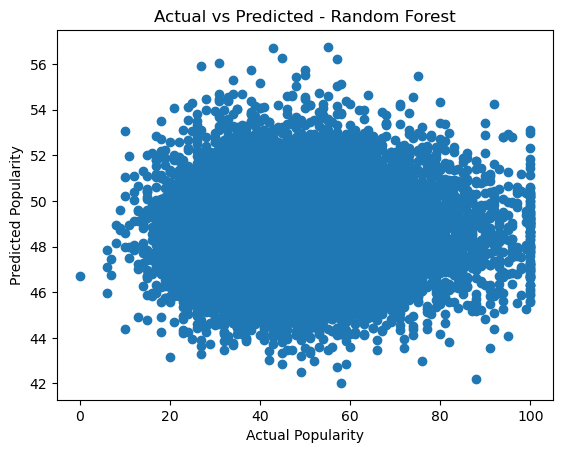

In [23]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Actual vs Predicted - Random Forest")
plt.show()

## Second Random Forest with GridSearchCV

In [40]:
# Find the best parameters for Random Forest Regression

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [10, 20, None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,),

{'max_depth': 10, 'n_estimators': 400}


In [44]:
rf2 = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    random_state=42,
    n_jobs=1
)

rf2.fit(X_train_scaled, y_train)

y_pred_rf2 = rf2.predict(X_test_scaled)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [46]:
print("RANDOM FOREST IMPROVED PARAMS RESULTS")

r2 = r2_score(y_test, y_pred_rf2)
mae = mean_absolute_error(y_test, y_pred_rf2)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf2))

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

RANDOM FOREST IMPROVED PARAMS RESULTS
R2: -0.0007531316120570342
MAE: 11.51900881888315
RMSE: 14.831073299852772


After performing Hyperparameter Tuning using GridSearchCV, the R2 score for Random Forest slightly improved, however is still negative.

# Model 3 - Gradient Boosting Regression

In [19]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train_scaled, y_train)

y_pred_gb = gb.predict(X_test_scaled)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [20]:
print("GRADIENT BOOSTING RESULTS")
print("-------------------------")

r2 = r2_score(y_test, y_pred_gb)
mae = mean_absolute_error(y_test, y_pred_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


GRADIENT BOOSTING RESULTS
-------------------------
R2: -0.0031296167717906886
MAE: 11.53068418245182
RMSE: 14.848672508268308


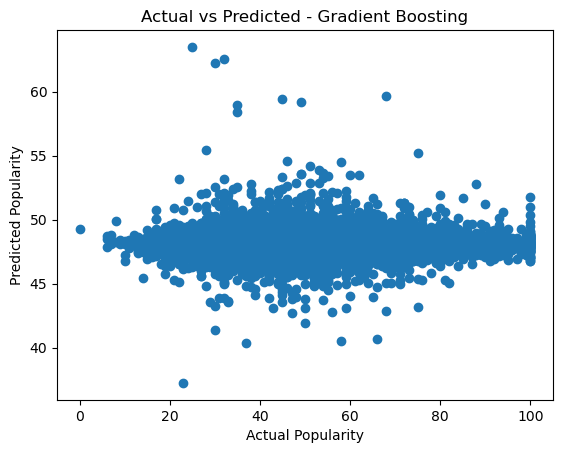

In [26]:
plt.scatter(y_test, y_pred_gb)
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Actual vs Predicted - Gradient Boosting")
plt.show()

## Second Gradient Boosting

In [42]:
# Find the best parameters for Random Forest Regression

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [10, 20, None]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:668: DataConversionWarning: A column-vector y w

{'max_depth': 10, 'n_estimators': 200}


In [47]:
gb2 = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=10,
    random_state=42
)

gb2.fit(X_train_scaled, y_train)

y_pred_gb2 = gb2.predict(X_test_scaled)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [48]:
print("GRADIENT BOOSTING RESULTS")
print("-------------------------")

r2 = r2_score(y_test, y_pred_gb2)
mae = mean_absolute_error(y_test, y_pred_gb2)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb2))

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

GRADIENT BOOSTING RESULTS
-------------------------
R2: -0.04452808996273161
MAE: 11.78845164357776
RMSE: 15.15197218099655


After performing HyperParamater tuning with the Gradient Boosting Regressor, the R2 score declined further into the negative.

# Model Comparison

In [21]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ]
})

results


,Model,R2,MAE,RMSE
0,Linear Regression,-0.000924,11.515795,14.832340
1,Random Forest,-0.013791,11.639644,14.927369
2,Gradient Boosting,-0.003130,11.530684,14.848673


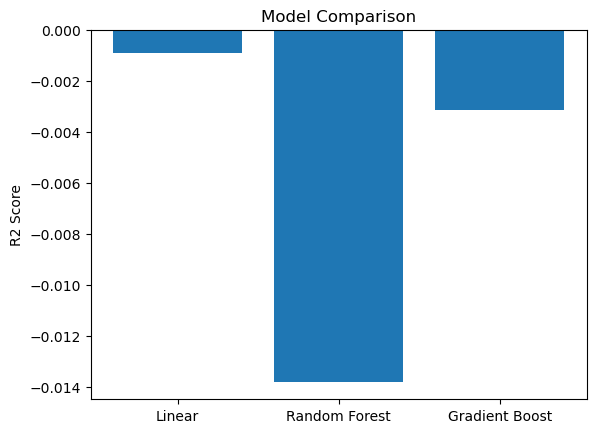

In [31]:
models = ["Linear", "Random Forest", "Gradient Boost"]
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_gb)
]

plt.bar(models, r2_scores)
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

In [38]:
baseline_pred = np.repeat(y_train.mean(), len(y_test))

rmse_baseline = np.sqrt(mean_squared_error(y_test, baseline_pred))
print("Baseline RMSE:", rmse_baseline)


Baseline RMSE: 14.826212214308708
